# Prediction of Obesity Risk Based On Lifestyle Factors

## Data Cleaning and Explanatory Data Analysis

### Objectives
* Data Ingestion & Cleaning: Load the UCI Obesity dataset (N = 2,111), rename variables for code readability and handle missing values.
* Type Conversion & Structuring: Reclassify `raw` object columns into explicit categorical variables to prepare for statistical analysis.
* Demographic & Lifestyle Profiling: Generate visualisations to understand sample age distribution, gender representation and behavioral traits across Mexico, Peru and Colombia affecting obesity.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import io
import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Data Ingestion & Cleaning

#### Dataset Retrieval

In [7]:
#Importing the dataset
obesity = pd.read_csv("obesity.csv")

#Generating random 10 samples
obesity.sample(10, random_state = 123)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
600,Female,19.010211,1.555431,44.188767,no,no,2.724285,3.000000,Frequently,no,1.000000,yes,1.070331,0.000000,Sometimes,Public_Transportation,Insufficient_Weight
1934,Female,25.783865,1.643111,109.910012,yes,yes,3.000000,3.000000,Sometimes,no,1.530992,no,0.015860,0.445495,Sometimes,Public_Transportation,Obesity_Type_III
1586,Male,25.509034,1.772190,114.097656,yes,yes,2.193310,3.000000,Sometimes,no,2.089983,no,1.360994,0.857438,Sometimes,Public_Transportation,Obesity_Type_II
1027,Female,33.690239,1.681842,77.426465,yes,yes,3.000000,2.679724,Sometimes,no,1.999737,no,1.747347,0.681773,no,Automobile,Overweight_Level_II
1758,Male,24.186273,1.794827,120.919703,yes,yes,2.611847,2.749334,Sometimes,no,2.364849,no,1.141708,0.063005,Sometimes,Public_Transportation,Obesity_Type_II
1790,Male,23.147644,1.815514,120.337664,yes,yes,2.996717,2.791366,Sometimes,no,2.626309,no,1.194898,0.034897,Sometimes,Public_Transportation,Obesity_Type_II
1523,Male,27.991467,1.825590,120.860386,yes,yes,3.000000,3.000000,Sometimes,no,3.000000,no,0.691369,1.415536,Sometimes,Public_Transportation,Obesity_Type_II
753,Male,21.962426,1.696336,75.000000,yes,yes,2.000000,3.000000,Sometimes,no,1.825629,no,0.699592,0.142056,Sometimes,Public_Transportation,Overweight_Level_I
1674,Male,27.939820,1.694642,99.709329,yes,yes,2.772027,2.454432,Sometimes,no,1.000000,no,0.858554,0.051268,no,Public_Transportation,Obesity_Type_II
289,Male,19.000000,1.880000,79.000000,no,no,2.000000,3.000000,Sometimes,no,3.000000,no,3.000000,0.000000,Sometimes,Automobile,Normal_Weight


#### Dataset Features

In [9]:
from tabulate import tabulate

table_ob = [["Name", "Data Type", "Units", "Description"], 
            ["Gender", "Binary", "NA", "Identity - Male or Female"], 
            ["Age", "Numeric", "Year", "Number of years from birth"],
            ["Height", "Numeric", "Metre", "Length of an individual"],
            ["Weight", "Numeric", "Kilogram", "Mass of an individual"],
            ["family_history_with_overweight", "Binary", "NA", "Prevalence of overweight and obesity across multiple generations"],
            ["FAVC", "Binary", "NA", "Intake of high calorie meal"],
            ["FCVC", "Numeric", "NA", "Intake of number of vegetables in meals"],
            ["NCP", "Numeric", "NA", "Daily frequency of meal intake"],
            ["CAEC", "Categorical", "NA", "Intake of food between meals"],
            ["Smoke", "Binary", "NA", "Smoking habits of an individual"],
            ["CH20", "Numeric", "Litre", "Daily water intake"],
            ["SCC", "Binary", "NA", "Engaging in daily calorie measurement"],
            ["FAF", "Numeric", "Day", "Frequency of excercise"],
            ["TUE", "Numeric", "Hour", "Frequency of technology use"],
            ["CALC", "Catgorical", "NA", "Intake of alcohol"],
            ["MTRANS", "Categorical", "NA", "Mode of transport"],
            ["NObeyesdad", "Categorical", "NA", "Level of obesity"]]

print(tabulate(table_ob, headers = "firstrow", tablefmt = 'fancy_grid'))         

╒════════════════════════════════╤═════════════╤══════════╤══════════════════════════════════════════════════════════════════╕
│ Name                           │ Data Type   │ Units    │ Description                                                      │
╞════════════════════════════════╪═════════════╪══════════╪══════════════════════════════════════════════════════════════════╡
│ Gender                         │ Binary      │ NA       │ Identity - Male or Female                                        │
├────────────────────────────────┼─────────────┼──────────┼──────────────────────────────────────────────────────────────────┤
│ Age                            │ Numeric     │ Year     │ Number of years from birth                                       │
├────────────────────────────────┼─────────────┼──────────┼──────────────────────────────────────────────────────────────────┤
│ Height                         │ Numeric     │ Metre    │ Length of an individual                            

#### Target Feature

The target feature for this dataset is 'NObeyesdad', i.e., the level of obesity in Mexico, Peru and Colombia. The levels are: 
- Insufﬁcient Weight
- Normal Weight
- Overweight Level I
- Overweight Level II
- Obesity Type I
- Obesity Type II
- Obesity Type III

#### Data Cleaning

In [13]:
#Renaming columns of the dataset to simplify complicated strings
obesity = obesity.rename(columns = {"family_history_with_overweight": "FAMHIS",
                                    "FAVC": "CALORIE",
                                    "FCVC": "VEG",
                                    "NCP": "MEAL",
                                    "CAEC": "BTW",
                                    "SCC": "CALOM",
                                    "FAF": "EXC",
                                    "TUE": "TECH",
                                    "CALC": "ALCO",
                                    "NObeyesdad": "OBS"})

#Convert the column names to lowercase
obesity.columns = obesity.columns.str.lower()

#Removing whitespaces in from the column names
obesity.columns = obesity.columns.str.strip()

#Removing whitespaces present in the categorical variables
whitespace_counts = {}
for col in obesity.columns:
    if obesity[col].dtype == 'object':
        whitespace_counts[col] = obesity[col].astype(str).apply(lambda x: x.isspace()).sum()

print("Whitespace counts per column:")
for col, count in whitespace_counts.items():
    print(f"Column '{col}': {count}")

#Checking for missing values for each column
print(obesity.isnull().sum())

Whitespace counts per column:
Column 'gender': 0
Column 'famhis': 0
Column 'calorie': 0
Column 'btw': 0
Column 'smoke': 0
Column 'calom': 0
Column 'alco': 0
Column 'mtrans': 0
Column 'obs': 0
gender     0
age        0
height     0
weight     0
famhis     0
calorie    0
veg        0
meal       0
btw        0
smoke      0
ch2o       0
calom      0
exc        0
tech       0
alco       0
mtrans     0
obs        0
dtype: int64


### Type Conversion & Structuring

In [15]:
#Checking the data types
print(f"Shape of the dataset = {obesity.shape} \n")
print(obesity.dtypes)

#Converting data types
obesity['gender'] = obesity['gender'].astype('category')
obesity['famhis'] = obesity['famhis'].astype('category')
obesity['calorie'] = obesity['calorie'].astype('category')
obesity['btw'] = obesity['btw'].astype('category')
obesity['smoke'] = obesity['smoke'].astype('category')
obesity['calom'] = obesity['calom'].astype('category')
obesity['alco'] = obesity['alco'].astype('category')
obesity['mtrans'] = obesity['mtrans'].astype('category')
obesity['obs'] = obesity['obs'].astype('category')

#Final check of data types
print(f"Shape of the dataset = {obesity.shape} \n")
print(obesity.dtypes)

Shape of the dataset = (2111, 17) 

gender      object
age        float64
height     float64
weight     float64
famhis      object
calorie     object
veg        float64
meal       float64
btw         object
smoke       object
ch2o       float64
calom       object
exc        float64
tech       float64
alco        object
mtrans      object
obs         object
dtype: object
Shape of the dataset = (2111, 17) 

gender     category
age         float64
height      float64
weight      float64
famhis     category
calorie    category
veg         float64
meal        float64
btw        category
smoke      category
ch2o        float64
calom      category
exc         float64
tech        float64
alco       category
mtrans     category
obs        category
dtype: object


### Demographic & Lifestyle Profiling

#### Statistical Summaries

In [18]:
#Statistical summary for numerical variables
obesity.describe()

,age,height,weight,veg,meal,ch2o,exc,tech
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [19]:
#Statistical summary for categorical variables
obesity.describe(include = 'category')

,gender,famhis,calorie,btw,smoke,calom,alco,mtrans,obs
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


In [20]:
#Statistical summary of obs variable
obesity['obs'].value_counts(normalize = 'TRUE') * 100

obs
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64

The average age of the population is around 24, with minimum age being 14 and maximum age being 61.  This implies that the majority of the population is relatively young. Among them over 85 per cent of the population consume high-calorie diet and exercise for an average of 1 hours. Linking that to obesity, over 80 per cent of the individuals have a family history of obesity and 45 per cent of them are diagnosed with obesity.

#### Univariate Visualisation

##### Histogram and Boxplot of Age

<Figure size 2000x1000 with 0 Axes>

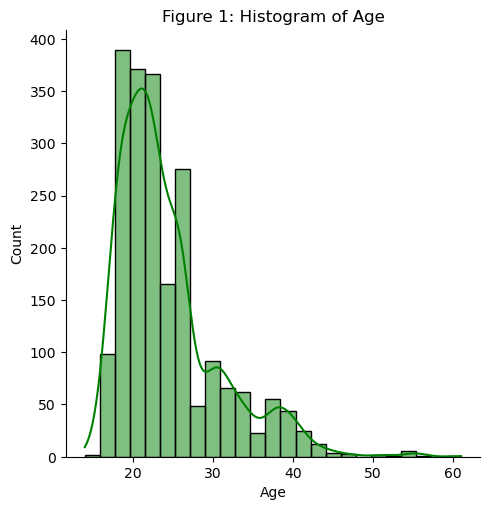

In [24]:
#Histogram for age
plt.figure(figsize = (20,10))
sns.displot(obesity['age'], bins = 25, kde = 'TRUE', color = 'green')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Figure 1: Histogram of Age')
plt.show()

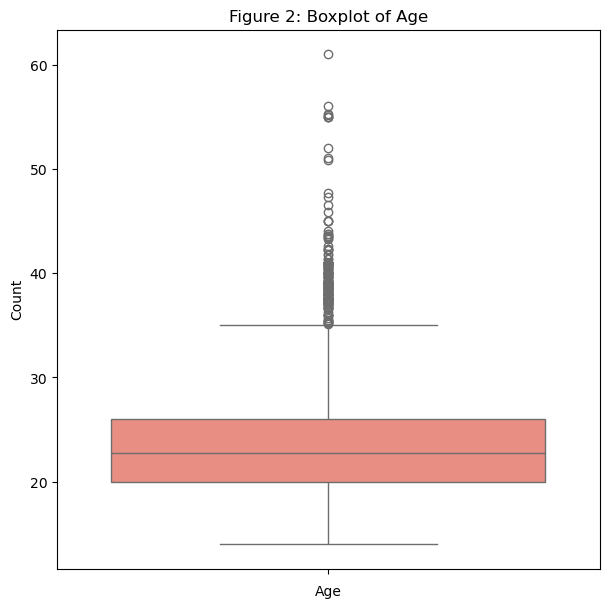

In [25]:
#Boxplot for age
plt.figure(figsize = (7,7))
sns.boxplot(obesity['age'], color = 'salmon')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Figure 2: Boxplot of Age')
plt.show()

According to the histogram of the age variable, the shape of the graph is not symmetrical, i.e, the distribution is not normal. The distribution is skewed to the right with 3 peaks indicating the presence of three distinct age subgroups. The histogram also shows that 50 per cent of the population are in their 20s. This is also observed visually in the boxplot and 75 per cent of the population is aged below 25 years. Points outside the whiskers of the boxplot indicate the presence of outliers. So, individuals aged 35 and above are considered to be outliers showing that the data is rich with young adults.

##### Bar Chart of Transport

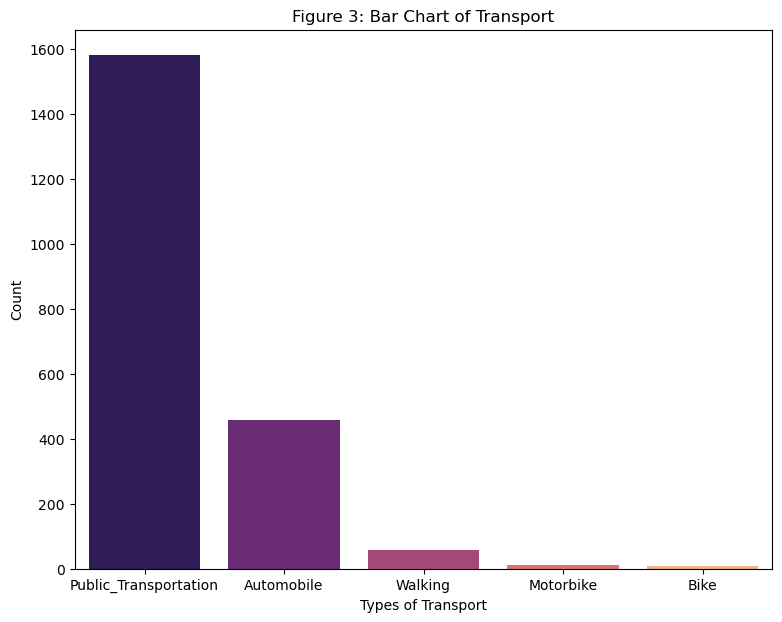

In [28]:
#Bar chart for transport
plt.figure(figsize = (9,7))
sns.countplot(x = 'mtrans', data = obesity, palette = 'magma', order = obesity['mtrans'].value_counts().index)
plt.xlabel('Types of Transport')
plt.ylabel('Count')
plt.title('Figure 3: Bar Chart of Transport')
plt.show()

##### Violin Plot of Daily Meal Intake

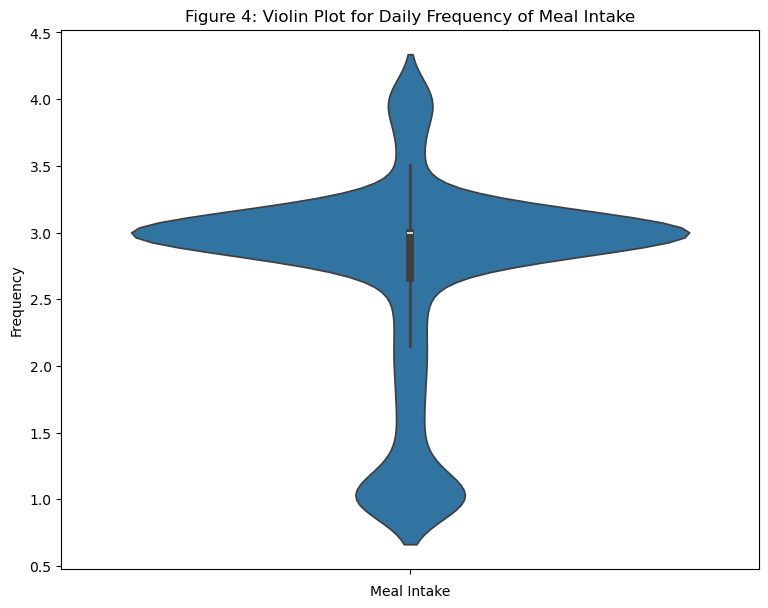

In [30]:
#Violin plot for meal
plt.figure(figsize = (9,7))
sns.violinplot(obesity['meal'])
plt.xlabel('Meal Intake')
plt.ylabel('Frequency')
plt.title('Figure 4: Violin Plot for Daily Frequency of Meal Intake')
plt.show()

The violin plot uses a kernel density estimation (KDE) to estimate the probability function of a random variable. In the meal intake graph, the centred white dot represents the median of the distribution, which is 3, i.e., 50 per cent of the individuals consume at most 3 meals a day. This also coincides with widest section of the plot, indicating higher density. The ends of the violin plot show the minimum and maximum meals consumed daily which is 0.6 and 4.4 respectively. 

#### Bivariate Visualisation

##### Boxplot of Smoke and Weight

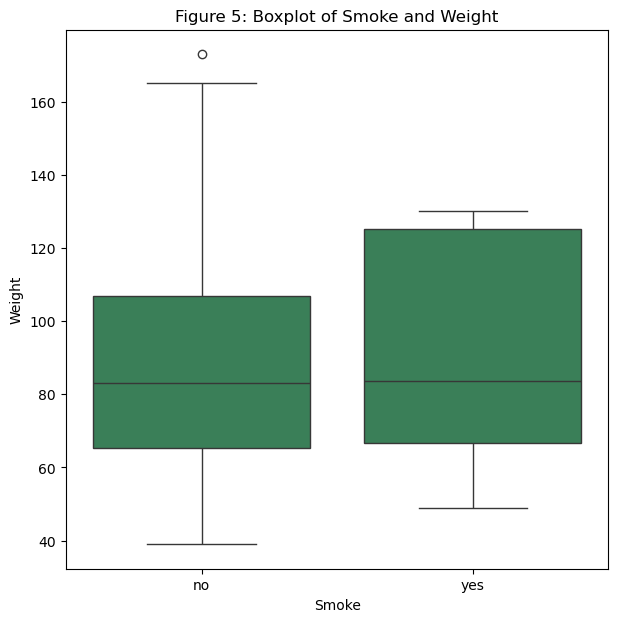

In [34]:
#Box plot of smoke and weight
plt.figure(figsize = (7,7))
sns.boxplot(x = 'smoke', y = 'weight', data = obesity, color = 'seagreen')
plt.xlabel('Smoke')
plt.ylabel('Weight')
plt.title('Figure 5: Boxplot of Smoke and Weight')
plt.show()

The boxplot reveals that the median weight of individuals regardless of their smoking habits is the same, around 81 kgs. However, the top 25 per cent of individuals who do not smoke weigh more than those who do smoke. The weight range of non-smokers is also larger than those who do. There is one individual who has considerably higher weight among the non-smokers compared to the rest of their group and the smoker group. 

##### Clustered Bar Chart of Gender and Obesity Risk

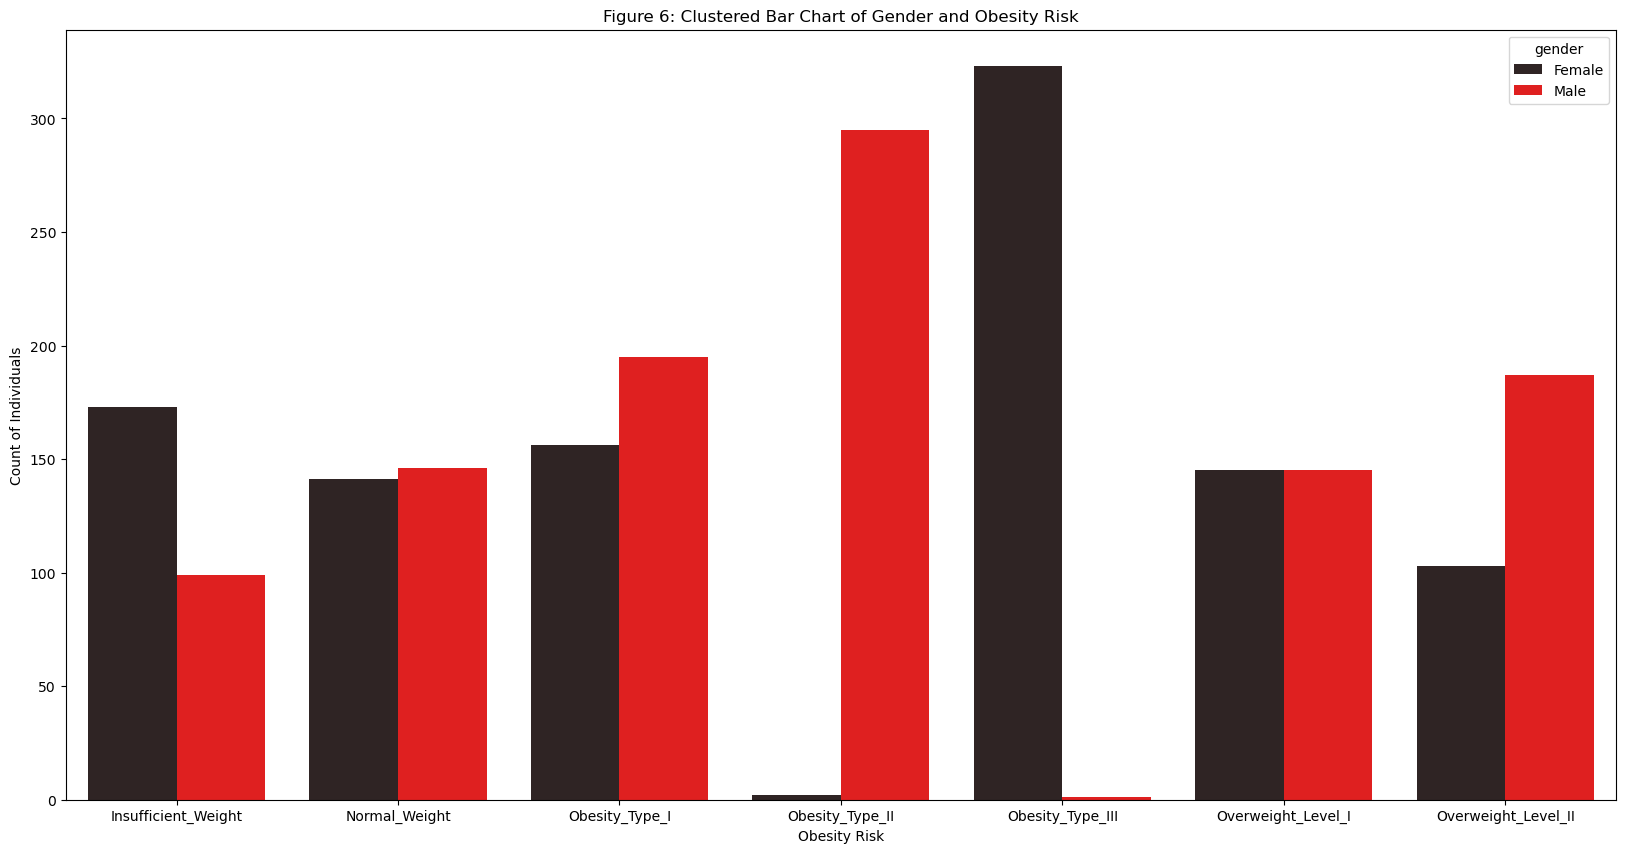

In [37]:
#Calculating the count of gender in each risk level of obesity
df_gen = obesity.groupby(['gender', 'obs']).size().reset_index(name = 'count')

#Stacked bar chart of gender and obesity risk
plt.figure(figsize = (20,10))
sns.barplot(x = 'obs', y = 'count', hue = 'gender', data = df_gen, color = 'red')
plt.xlabel('Obesity Risk')
plt.ylabel('Count of Individuals')
plt.title('Figure 6: Clustered Bar Chart of Gender and Obesity Risk')
plt.show()

##### Clustered Bar Chart of Family History and Obesity Risk

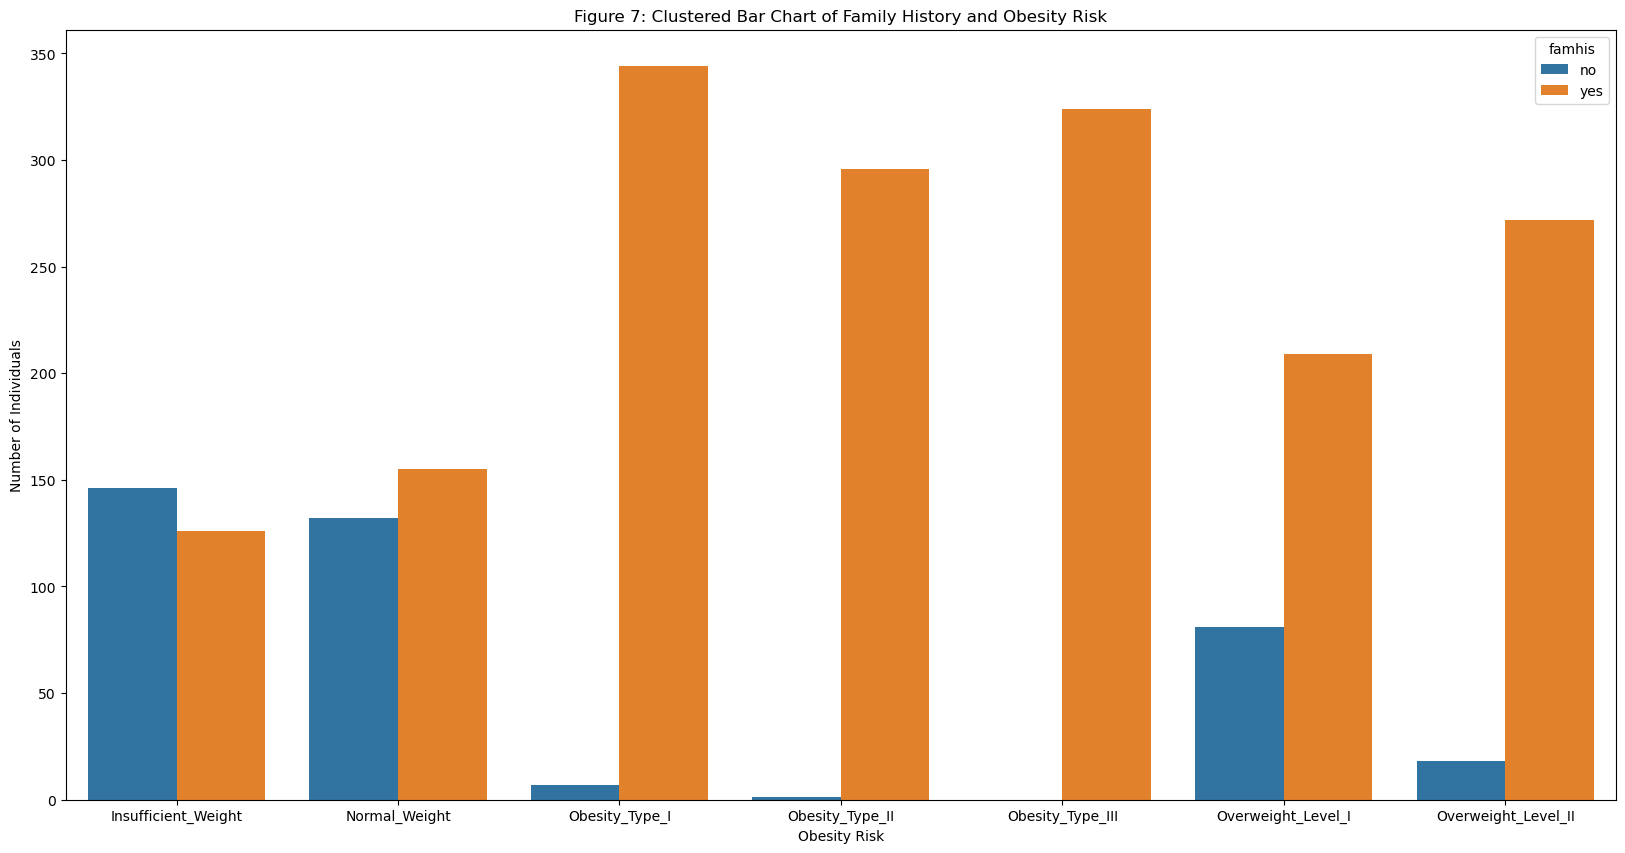

In [39]:
#Calculating the count of individuals with family history in each risk level of obesity
df_obs = obesity.groupby(['obs', 'famhis']).size().reset_index(name='count')

#Clustered bar chart of famhis and obs
plt.figure(figsize = (20,10))
sns.barplot(x = 'obs', y = 'count', hue = 'famhis', data = df_obs)
plt.xlabel('Obesity Risk')
plt.ylabel('Number of Individuals')
plt.title('Figure 7: Clustered Bar Chart of Family History and Obesity Risk')
plt.show()

The clustered bar chart examines whether individuals with family history of obesity are currently diagnosed with a certain level of obesity. For individuals classified as having insufficient or normal weight, the number of individuals without a family history of obesity is higher than those with a family history.
Conversely, it is observed that the majority of individuals who have a family history of obesity are either obese or overweight. Thus, there is a positive association between family history and risk of obesity. 

##### Heatmap of Gender and Alcohol Consumption

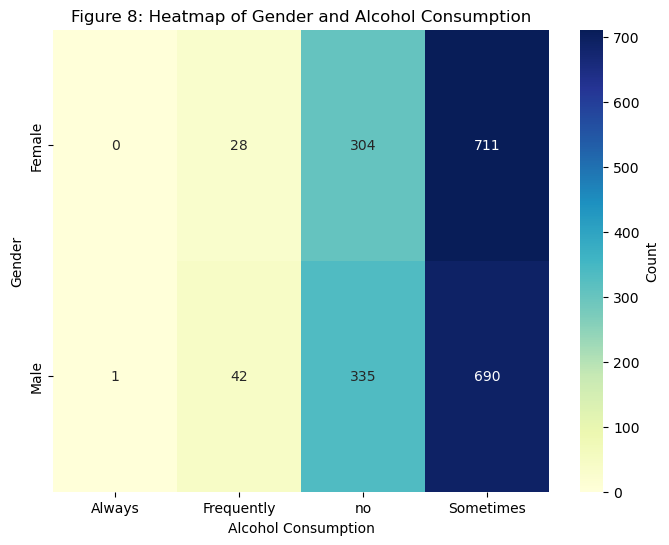

In [42]:
#Creating a contingency table for gender and alcohol
table = pd.crosstab(obesity['gender'], obesity['alco'])
table_sorted = table.loc[:, table.sum(axis=0).sort_values().index]

#Heatmap of gender and alcohol consumption
plt.figure(figsize = (8, 6))
sns.heatmap(table_sorted, annot = True, fmt = 'd', cmap = 'YlGnBu', cbar_kws = {'label': 'Count'})
plt.title('Figure 8: Heatmap of Gender and Alcohol Consumption')
plt.xlabel('Alcohol Consumption')
plt.ylabel('Gender')
plt.show()

#### Multivariate Visualisation

##### Contour Chart of BMI, Age and Obesity

<Figure size 800x800 with 0 Axes>

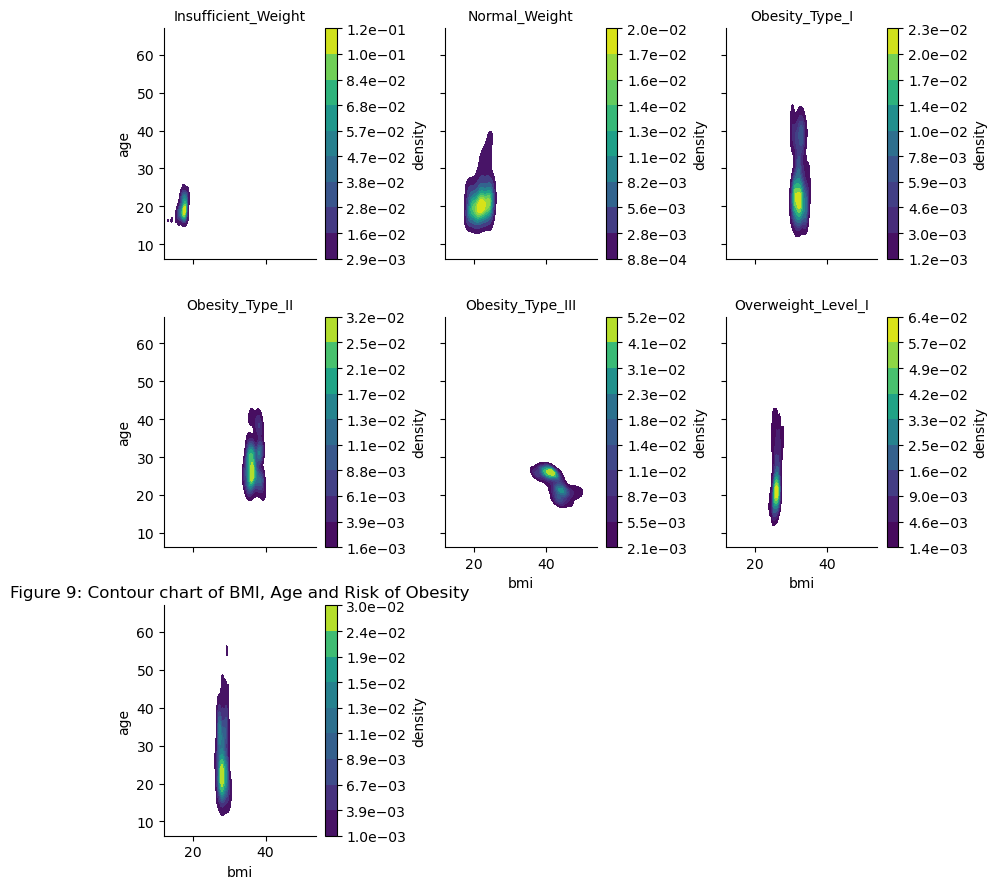

In [45]:
#Creating the BMI variable
obesity['bmi'] = obesity['weight']/(obesity['height']**2)

#Contour chart of bmi, age and obs
plt.figure(figsize = (8, 8))
plot = sns.FacetGrid(obesity, col  ='obs', col_wrap = 3)
plot.map(sns.kdeplot, 'bmi', 'age', fill = True, cmap = 'viridis', cbar = True, cbar_kws = {'label': 'density', 'format': '{x:.1e}'})
plot.set_titles(col_template = "{col_name}")
plt.title('Figure 9: Contour chart of BMI, Age and Risk of Obesity')
plt.tight_layout()
plt.show()

The contour chart provides information on population's age and bmi with relation the obesity risk level. The colour intensity within each subplot represents the density of individuals with that particular combination of BMI and age for that specific obesity risk category.
Under insufficient weight, the density is concentrated in a small region with low BMI and a younger age group. Whereas for obesity type-III the density is concentrated in a region with the highest BMI (around 40 - 50) and an age group of 25-35 years old.
Overall, the grid reveals that lower weight categories are associated with low BMI and a younger population. While higher weight categories (overweight and obese) are associated with higher BMIs and include a diverse age range. 

##### Scatterplot of Techonology Use, Excerise Hours and Calorie Measurement

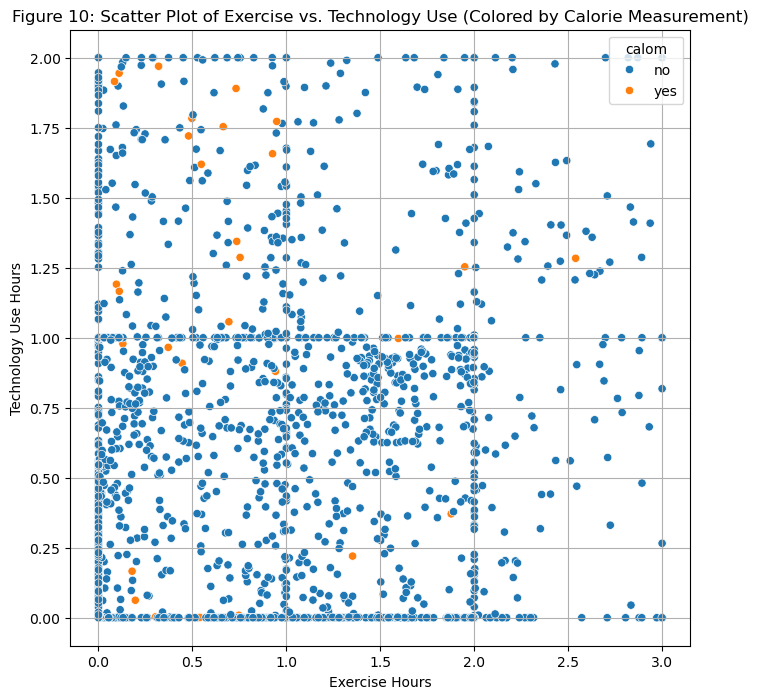

In [48]:
# Scatterplot of tech, exc and calom
plt.figure(figsize = (8, 8))
sns.scatterplot(data = obesity, x ='exc', y = 'tech', hue = 'calom').legend(title = 'calom', loc = 'upper right')
plt.xlabel('Exercise Hours')
plt.ylabel('Technology Use Hours')
plt.title('Figure 10: Scatter Plot of Exercise vs. Technology Use (Colored by Calorie Measurement)')
plt.grid(True)
plt.show()

The scatterplot visualises the relationship between exercise hours and use of technology with the coloured points indicating whether an individual measures their calories or not.
There are a large number of data points spread across the plot with no pattern implying that there is no correlation between the two variables. Those who do measure their calories are clustered in the top left corner. So, individuals with low exercise hours and high consumption technology often measure their calories.

##### Point Plot of Water Intake, Consumption of Food Between Meals and Intake of High Calorie Meals.

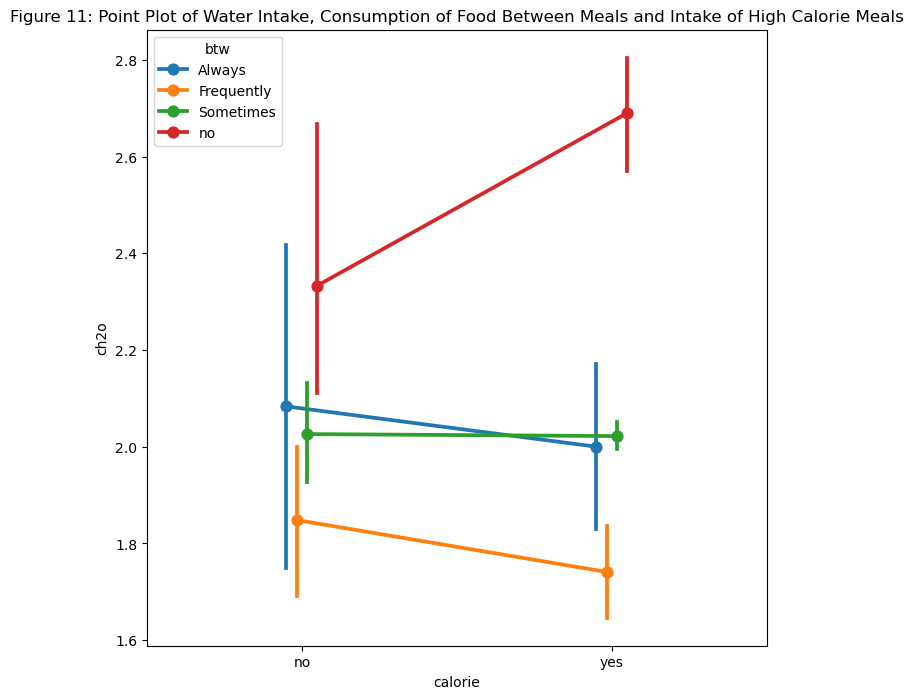

In [51]:
#Point plot between calorie, ch2o and btw
plt.figure(figsize = (8, 8))
sns.pointplot(x ='calorie', y ='ch2o', hue = 'btw', data = obesity, dodge = True).legend(title = 'btw', loc = 'upper left')
plt.title('Figure 11: Point Plot of Water Intake, Consumption of Food Between Meals and Intake of High Calorie Meals')
plt.show()

The point plot provides a visual presentation of the relationship between intake of high calorie meals (indicated as calorie), water intake and consumption of food between meals. The vertical lines represent the error bars or confidence intervals for the mean intake of water for each group.
Considering no food consumption between meals, the mean water intake of individuals is relatively higher than the other groups. However, there is a significant difference in the mean water intake of those who do not consume high calorie diet and those who do. 
The overlapping confidence bars of the groups - sometimes and always suggest that the mean water intake of these two groups is not statistically significant. 
The individuals who frequently consume food between meals have the lowest mean water intake for both calorie groups. 

Overall, there is a complex interaction between the three variables.

In [53]:
#Exporting the cleaned dataset
obesity.to_csv('obesity_cleaned.csv', index = False)